# 1. 가상 데이터 셋을 생성한 뒤, 학습·검증·테스트 데이터셋으로 분할해 보세요.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

data_set = np.random.random((1000,32,32,3))

train_set, temp_set = train_test_split(data_set, test_size=0.4, random_state=42)

test_set, valid_set = train_test_split(temp_set, test_size=0.5, random_state=42)

print(f'Train set: {len(train_set)}, Valid set: {len(valid_set)}, Test set: {len(test_set)}')

Train set: 600, Valid set: 200, Test set: 200


# 2. 가상 데이터셋을 생성하고, K-최근접이웃(K-NN) 알고리즘으로 학습·예측을 수행해 보세요.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
input_dim = 20
num_classes = 10
trainset_num = 1000
testset_num = 200

X_train = np.random.rand(trainset_num,input_dim).astype(np.float32) # trainset_num x 20
y_train = np.random.randint(num_classes, size=(trainset_num)).astype(np.int64) # (trainset_num,)

X_test = np.random.rand(testset_num,input_dim).astype(np.float32) # testset_num x 20
y_test = np.random.randint(num_classes, size=(testset_num)).astype(np.int64) # (testset_num,)

print(y_train.shape)

(1000,)


In [ ]:
# K-NN 모델 생성
k = 5
knn_model = KNeighborsClassifier(n_neighbors=k)

#모델 학습
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# 모델 평가
accuracy = knn_model.score(X_test, y_test)
print(f"accuracy: {accuracy}")

# 샘플 데이터 예측
sample = X_test[0].reshape(1,-1) # 인덱싱으로 축이 하나 줄어들었으므로 입력 데이터 shape 맞춰주기
prediction = knn_model.predict(sample)
print(f"Prediction: {prediction[0]}")

accuracy: 0.09
Prediction: 2


# 3. 동일한 이진 분류 가상 데이터셋을 생성하고, Perceptron, SVM, Random Forest, Naive Bayes 네 가지 알고리즘으로 학습해 보세요.

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
import numpy as np

# 이진 분류 가상 데이터셋 생성
input_dim = 20
num_classes = 2
trainset_num = 1000
testset_num = 200

X_train = np.random.rand(trainset_num,input_dim).astype(np.float32) # trainset_num x 20
y_train = np.random.randint(num_classes, size=(trainset_num)).astype(np.int64) # (trainset_num,)

X_test = np.random.rand(testset_num,input_dim).astype(np.float32) # testset_num x 20
y_test = np.random.randint(num_classes, size=(testset_num)).astype(np.int64) # (testset_num,)


In [ ]:
# Perceptron
pn_model = Perceptron(random_state=42)

# SVM
svm_model = SVC(kernel='linear')

# RandomForest
rf_model1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model2 = RandomForestClassifier(n_estimators=100, max_depth=10,random_state=42)

# Naive Bayes
nb_model = GaussianNB()


In [ ]:
# 모델 학습
pn_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
rf_model1.fit(X_train, y_train)
rf_model2.fit(X_train, y_train)
nb_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
# 모델 평가
ppn_accuracy = pn_model.score(X_test, y_test)
svm_accuracy = svm_model.score(X_test, y_test)
rf1_accuracy = rf_model1.score(X_test, y_test)
rf2_accuracy = rf_model2.score(X_test, y_test)
nb_accuracy = nb_model.score(X_test, y_test)

print(f"perceptron {ppn_accuracy}, svm {svm_accuracy}, rf1 {rf1_accuracy}, rf2 {rf2_accuracy}, nb {nb_accuracy}")

perceptron 0.56, svm 0.465, rf1 0.465, rf2 0.425, nb 0.5


In [ ]:
# 모델 예측
sample = X_test[0].reshape(1,-1)

pn_prediction = pn_model.predict(sample)[0]
svm_prediction = svm_model.predict(sample)[0]
rf1_prediction = rf_model1.predict(sample)[0]
rf2_prediction = rf_model2.predict(sample)[0]
nb_prediction = nb_model.predict(sample)[0]

print(f"perceptron {pn_prediction}, svm {svm_prediction}, rf1 {rf1_prediction}, rf2 {rf2_prediction}, nb {nb_prediction}")


perceptron 0, svm 0, rf1 0, rf2 0, nb 0


# 4. 가상 데이터셋을 준비하고, 증강(Data Augmentation) 기법을 적용했을 때와 적용하지 않았을 때 모델 성능을 비교하세요.

In [ ]:
import time
import datetime

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [ ]:
# Torchvision.datasets 를 이용해 CIFAR-10 사용

#1. 원본 데이터의 transform (데이터 증강을 적용하지 않음)
transform_original = transforms.Compose([
    # 픽셀 값을 255로 나누어 0.~1. 사이의 값으로 바꿔줌(float32)
    # 차원 순서 변경 (HWC -> CHW) 파이토치 텐서
    transforms.ToTensor(),

    #픽셀 값을 표준화 (데이터 정규화), 데이터의 중심을 0 근처로 맞추고 채널별 편차를 균일하게
    # 앞의 (0.5,0.5,0.5): R,G,B 각 채널의 평균, 뒤: R,G,B 각 채널의 표준편차
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5,0.5,0.5))


])
#2. 데이터 증강을 위한 transform
transform_augmented = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees = 15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5,0.5,0.5))
])


In [ ]:
# CIFAR-10 다운로드 (10minutes)
# Dataset

# 데이터 증강 적용하지 않은 오리지널 데이터와 데이터 증강 적용한 것
trainset_original = torchvision.datasets.CIFAR10(root='./data',train=True, download=True, transform=transform_original)
trainset_augmented = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_augmented)

#Test set은 데이터 증강을 적용하면 안된다.
testset = torchvision.datasets.CIFAR10(root='./data',train=False, download=True,transform=transform_original)

100%|██████████| 170M/170M [09:10<00:00, 310kB/s]


In [ ]:
# DataLoader
train_loader_original = DataLoader(trainset_original, batch_size=32, shuffle=True)
train_loader_augmented = DataLoader(trainset_augmented, batch_size=32, shuffle=True)

test_loader = DataLoader(testset, batch_size=32, shuffle=False)

In [ ]:
# 모델 설계(SimpleCNN) 강의 교재 참고

# CIFAR-10 shape : 32x32
num_classes = 10

class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # output size 그대로
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # output size 1/2
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(128 *4*4, 256)
    self.fc2 = nn.Linear(256, num_classes) # output layer

  def forward(self, x):
    x = self.pool(torch.relu(self.conv1(x))) # Nx16x16x32
    x = self.pool(torch.relu(self.conv2(x))) # Nx8x8x64
    x = self.pool(torch.relu(self.conv3(x))) # Nx4x4x128
    x = self.flatten(x) #
    x = torch.relu(self.fc1(x))
    x = self.fc2(x) # output 이므로 activation 적용하지 않음
    return x


In [ ]:
# 모델 생성, 손실함수, 옵티마이저
# GPU 설정

model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

cuda:0


In [ ]:
# 데이터 증강 없이 학습  # 3분
num_epochs = 10
# 모델 학습
start = time.time()
for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  for inputs, labels in train_loader_original:
    # data to GPU
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad() # 초기화
    outputs= model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item() # tensor를 python 숫자 형태로
  if (epoch+1) % 1 == 0:
    print(f'{epoch+1}/{num_epochs} Loss : {running_loss/len(train_loader_original)}')
end = time.time()
sec = end-start
times = str(datetime.timedelta(seconds=sec)).split(".")[0]
print(f"{times}")

1/10 Loss : 1.3536952701197629
2/10 Loss : 0.9162015677718726
3/10 Loss : 0.7379888392226939
4/10 Loss : 0.6112092303795
5/10 Loss : 0.5094858734217197
6/10 Loss : 0.4150047855724605
7/10 Loss : 0.33729729656742613
8/10 Loss : 0.2710713432602446
9/10 Loss : 0.21741200480145365
10/10 Loss : 0.18120543540753925


In [ ]:
# 모델 평가
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for inputs, labels in test_loader:
    # data to gpu
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model(inputs)
    _,predicted = torch.max(outputs, 1) # 각 출력에서 최댓값의 인덱스를 전달
    total += labels.size(0)
    correct += (predicted == labels).sum().item() #맞힌 개수

accuracy = correct / total
print(f'Test Accuracy without augmentation: {accuracy*100:.4f}')

Test Accuracy without augmentation: 73.5700


In [ ]:
# 데이터 증강 적용하여 학습
num_epochs = 10
# 모델 학습
start = time.time()
for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  for inputs, labels in train_loader_augmented:
    # data to GPU
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad() # 초기화
    outputs= model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item() # tensor를 python 숫자 형태로
  if (epoch+1) % 1 == 0:
    print(f'{epoch+1}/{num_epochs} Loss : {running_loss/len(train_loader_original)}')
end = time.time()
sec = end-start
times = str(datetime.timedelta(seconds=sec)).split(".")[0]
print(f"{times}")

1/10 Loss : 0.8079548008306165
2/10 Loss : 0.6996166357628748
3/10 Loss : 0.6587765452500268
4/10 Loss : 0.6292251021489834
5/10 Loss : 0.6098557964529812
6/10 Loss : 0.5872637911849272
7/10 Loss : 0.5668724150952817
8/10 Loss : 0.5579589603138672
9/10 Loss : 0.5384916257892598
10/10 Loss : 0.5205766493913384
0:06:55


In [ ]:
# 모델 평가
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for inputs, labels in test_loader:
    # data to GPU
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model(inputs)
    _,predicted = torch.max(outputs, 1) # 각 출력에서 최댓값의 인덱스를 전달
    total += labels.size(0)
    correct += (predicted == labels).sum().item() #맞힌 개수

accuracy = correct / total
print(f'Test Accuracy with augmentation: {accuracy*100:.4f}')

Test Accuracy with augmentation: 79.2900


# 5. 활성화 함수를 직접 정의하고, 활성화 함수를 적용한 출력을 계산하고, 결과를 그래프로 시각화하세요.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
dataset = np.arange(-10,10)

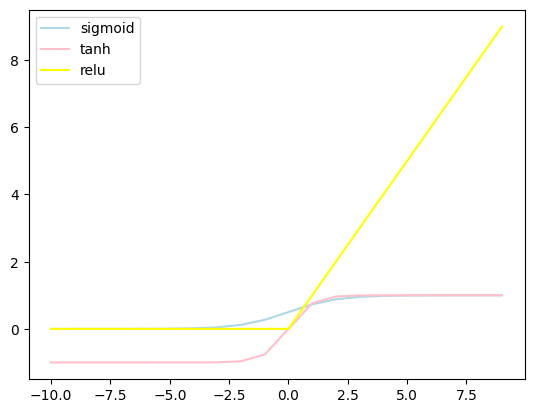

In [ ]:
def sigmoid(x):
  return 1 / (1+np.exp(-x))

def tanh(x):
  return np.tanh(x)

def relu(x):
  return np.maximum(0, x)


output_sigmoid = sigmoid(dataset)
output_tanh = tanh(dataset)
output_relu = relu(dataset)

plt.plot(dataset, output_sigmoid, color = 'lightblue', label = 'sigmoid')
plt.plot(dataset, output_tanh, color = 'pink', label = 'tanh')
plt.plot(dataset, output_relu, color = 'yellow', label = 'relu')
plt.legend()

# 6. 비선형 데이터셋을 생성하고, MLP(다층 퍼셉트론) 모델을 설계하고 학습시켜 분류를 수행하세요.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
#Iris 데이터셋
iris = load_iris()
X=iris.data
y=iris.target

num_classes = 3
input_dim = 4

X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(len(X_train), len(X_test))

# 데이터 정규화
scaler= StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

print(X_train.shape) # (120,4)

120 30
(120, 4)


In [ ]:
# PyTorch Tensor 변환 (Iris Data)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

In [ ]:
class MLP(nn.Module):
  def __init__(self, input_dim, num_classes):
    super(MLP, self).__init__()
    self.fc1 = nn.Linear(input_dim, 64)
    self.fc2 = nn.Linear(64,64)
    self.fc3 = nn.Linear(64, num_classes)

  def forward(self, x):
    x = torch.relu(self.fc1(x))
    x = torch.relu(self.fc2(x))
    x = self.fc3(x)

    return x

model = MLP(input_dim, num_classes)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 20
for epoch in range(num_epochs):
  model.train()
  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

  print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/20], Loss: 0.7193
Epoch [2/20], Loss: 0.7587
Epoch [3/20], Loss: 0.5787
Epoch [4/20], Loss: 0.3346
Epoch [5/20], Loss: 0.3332
Epoch [6/20], Loss: 0.3082
Epoch [7/20], Loss: 0.4081
Epoch [8/20], Loss: 0.3472
Epoch [9/20], Loss: 0.2091
Epoch [10/20], Loss: 0.2178
Epoch [11/20], Loss: 0.2659
Epoch [12/20], Loss: 0.2077
Epoch [13/20], Loss: 0.0927
Epoch [14/20], Loss: 0.1089
Epoch [15/20], Loss: 0.0619
Epoch [16/20], Loss: 0.1255
Epoch [17/20], Loss: 0.1155
Epoch [18/20], Loss: 0.0364
Epoch [19/20], Loss: 0.2235
Epoch [20/20], Loss: 0.1212


In [ ]:
model.eval()
with torch.no_grad():
  for inputs, labels in test_loader:
    outputs = model(inputs)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 79.41%


In [ ]:
sample_input = X_test_tensor[:5] ####
#print(sample_input.dtype)
predictions = model(sample_input)
_, predicted_classes = torch.max(predictions, 1)
print("Predicted classes: ", predicted_classes.numpy())
print("True classes: ", y_test[:5])

torch.float32
Predicted classes:  [1 0 2 1 1]
True classes:  [1 0 2 1 1]


# 7. CNN(Convolutional Neural Network)을 직접 구성하여 이미지 분류를 수행하세요.

In [26]:
import time
import datetime

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [27]:
# Torchvision.datasets 를 이용해 CIFAR-10 사용

#원본 데이터의 transform (데이터 증강을 적용하지 않음)
transform = transforms.Compose([
    # 픽셀 값을 255로 나누어 0.~1. 사이의 값으로 바꿔줌(float32)
    # 차원 순서 변경 (HWC -> CHW) 파이토치 텐서
    transforms.ToTensor(),

    #픽셀 값을 표준화 (데이터 정규화), 데이터의 중심을 0 근처로 맞추고 채널별 편차를 균일하게
    # 앞의 (0.5,0.5,0.5): R,G,B 각 채널의 평균, 뒤: R,G,B 각 채널의 표준편차
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5,0.5,0.5))

])

In [28]:
# CIFAR-10 다운로드 (2초..?)
# Dataset

trainset = torchvision.datasets.CIFAR10(root='./data',train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data',train=False, download=True,transform=transform)

In [29]:
# DataLoader
train_loader = DataLoader(trainset, batch_size=32, shuffle=True)
test_loader = DataLoader(testset, batch_size=32, shuffle=False)

In [30]:
import torch.nn as nn
import torch
# CIFAR-10 shape : 32x32
num_classes = 10

# 모델 생성 (SimpleCNN) VGG16과 비슷
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # output size 그대로
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # output size 1/2
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(128 *4*4, 512)
    self.fc2 = nn.Linear(512, num_classes) # output layer

  def forward(self, x):
    x = self.pool(torch.relu(self.conv1(x)))
    x = self.pool(torch.relu(self.conv2(x)))
    x = self.pool(torch.relu(self.conv3(x)))
    x = self.flatten(x)
    x = torch.relu(self.fc1(x))
    x = self.fc2(x) # output 이므로 activation 적용하지 않음
    return x

In [31]:
# 모델 생성, 손실함수, 옵티마이저
# GPU 설정

model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

cuda:0


In [32]:
# 학습  # num_epochs 10 : 3분
num_epochs = 10
# 모델 학습
start = time.time()
model.train()
for epoch in range(num_epochs):
  running_loss = 0.0
  for inputs, labels in train_loader:
    # data to GPU
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad() # 초기화
    outputs= model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item() # tensor를 python 숫자 형태로
  if (epoch+1) % 1 == 0:
    print(f'{epoch+1}/{num_epochs} Loss : {running_loss/len(train_loader)}')
end = time.time()
sec = end-start
times = str(datetime.timedelta(seconds=sec)).split(".")[0]
print(f"{times}")

1/10 Loss : 1.2983997422613094
2/10 Loss : 0.8572843642243955
3/10 Loss : 0.668364823836969
4/10 Loss : 0.5240648614334434
5/10 Loss : 0.39888629765367173
6/10 Loss : 0.29532946956296874
7/10 Loss : 0.2101994486685344
8/10 Loss : 0.1613504697806461
9/10 Loss : 0.1329737407353755
10/10 Loss : 0.10912261168253194
0:02:53


In [33]:
# 모델 평가
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for inputs, labels in test_loader:
    # data to gpu
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model(inputs)
    _,predicted = torch.max(outputs, 1) # 각 출력에서 최댓값의 인덱스를 전달
    total += labels.size(0)
    correct += (predicted == labels).sum().item() #맞힌 개수

accuracy = correct / total
print(f'Test Accuracy : {accuracy*100:.4f}')

Test Accuracy : 74.8800


In [ ]:
# 학습  # num_epochs 10 : 3분  num_epochs 100 : 30분 27초
num_epochs = 100
# 모델 학습
start = time.time()
for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  for inputs, labels in train_loader:
    # data to GPU
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad() # 초기화
    outputs= model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item() # tensor를 python 숫자 형태로
  if (epoch+1) % 10 == 0:
    print(f'{epoch+1}/{num_epochs} Loss : {running_loss/len(train_loader)}')
end = time.time()
sec = end-start
times = str(datetime.timedelta(seconds=sec)).split(".")[0]
print(f"{times}")

10/100 Loss : 0.13642764699026247
20/100 Loss : 0.07789459841352171
30/100 Loss : 0.07874891448161483
40/100 Loss : 0.0622106523722062
50/100 Loss : 0.06722822068653903
60/100 Loss : 0.06508033334746474
70/100 Loss : 0.06327250969739692
80/100 Loss : 0.06519245453881237
90/100 Loss : 0.06912228668951137
100/100 Loss : 0.07731076980097343
0:30:27


In [ ]:
# 모델 평가
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for inputs, labels in test_loader:
    # data to gpu
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model(inputs)
    _,predicted = torch.max(outputs, 1) # 각 출력에서 최댓값의 인덱스를 전달
    total += labels.size(0)
    correct += (predicted == labels).sum().item() #맞힌 개수

accuracy = correct / total
print(f'Test Accuracy : {accuracy*100:.4f}')

Test Accuracy : 73.1000
